#### CHANAKYA - AI Commerce Intelligence Platform
#### Layer 9: Churn Prediction
#### Author: Devesh Shukla

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     roc_auc_score, roc_curve, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']  = (12, 6)
plt.rcParams['font.size']       = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paths
PROCESSED_PATH = r'C:\Users\Dell\CHANAKYA\data\processed'
CHURN_PATH     = r'C:\Users\Dell\CHANAKYA\layer9_churn_prediction'

# Load data
df_orders      = pd.read_csv(f'{PROCESSED_PATH}/orders_processed.csv')
df_order_items = pd.read_csv(f'{PROCESSED_PATH}/order_items_processed.csv')
df_customers   = pd.read_csv(f'{PROCESSED_PATH}/customers_processed.csv')

df_orders['order_date']      = pd.to_datetime(df_orders['order_date'],      format='mixed')
df_order_items['order_date'] = pd.to_datetime(df_order_items['order_date'], format='mixed')

print("=" * 55)
print("   CHANAKYA — LAYER 9: CHURN PREDICTION")
print("=" * 55)
print(f"\nData loaded!")
print(f"  Orders      : {len(df_orders):,}")
print(f"  Order Items : {len(df_order_items):,}")
print(f"  Customers   : {len(df_customers):,}")
print(f"\nChurn Prediction started!")

   CHANAKYA — LAYER 9: CHURN PREDICTION

Data loaded!
  Orders      : 5,010
  Order Items : 8,769
  Customers   : 1,000

Churn Prediction started!


In [2]:
# Define Churn — not active from 6+ months
print("=" * 55)
print("   CHURN LABEL CREATION")
print("=" * 55)

reference_date = pd.Timestamp('2026-03-18')
churn_days     = 180  # 6 months

# Last order date per customer
last_order = df_orders.groupby('customer_id').agg(
    last_order_date = ('order_date',  'max'),
    total_orders    = ('order_id',    'nunique'),
    avg_discount    = ('discount_percent', 'mean'),
    cancel_count    = ('order_status', lambda x: (x == 'Cancelled').sum()),
    return_count    = ('order_status', lambda x: (x == 'Returned').sum()),
).reset_index()

last_order['days_since_last'] = (
    reference_date - last_order['last_order_date']
).dt.days

# Churn label — 1 = churned, 0 = active
last_order['is_churned'] = (last_order['days_since_last'] >= churn_days).astype(int)

# Customer features
customer_features = df_order_items.groupby('customer_id').agg(
    total_revenue   = ('revenue',       'sum'),
    avg_order_value = ('revenue',       'mean'),
    total_quantity  = ('quantity',      'sum'),
    unique_products = ('product_id',    'nunique'),
    unique_cats     = ('category',      'nunique'),
    max_order_val   = ('total_amount',  'max'),
).reset_index()

# Merge all features
churn_df = last_order.merge(customer_features, on='customer_id', how='left')
churn_df = churn_df.merge(
    df_customers[['customer_id','age','gender','tier','is_premium','signup_date']],
    on='customer_id', how='left'
)

# Additional features
churn_df['signup_date']   = pd.to_datetime(churn_df['signup_date'])
churn_df['customer_age_days'] = (reference_date - churn_df['signup_date']).dt.days
churn_df['cancel_rate']   = churn_df['cancel_count'] / churn_df['total_orders']
churn_df['return_rate']   = churn_df['return_count'] / churn_df['total_orders']
churn_df['gender_code']   = (churn_df['gender'] == 'Male').astype(int)
churn_df['tier_code']     = churn_df['tier'].map({'Tier 1': 3, 'Tier 2': 2, 'Tier 3': 1})
churn_df['is_premium']    = churn_df['is_premium'].astype(int)
churn_df                  = churn_df.fillna(0)

churned  = churn_df['is_churned'].sum()
active   = len(churn_df) - churned

print(f"\nChurn Labels Created!")
print(f"  Total Customers  : {len(churn_df):,}")
print(f"  Churned          : {churned:,} ({churned/len(churn_df)*100:.1f}%)")
print(f"  Active           : {active:,} ({active/len(churn_df)*100:.1f}%)")
print(f"  Churn Threshold  : {churn_days} days (6 months)")

print(f"\nChurned Customer Profile:")
churned_df = churn_df[churn_df['is_churned'] == 1]
active_df  = churn_df[churn_df['is_churned'] == 0]
print(f"  {'Metric':<22} {'Churned':>12} {'Active':>12}")
print(f"  {'-'*22} {'-'*12} {'-'*12}")
print(f"  {'Avg Orders':<22} {churned_df['total_orders'].mean():>12.1f} {active_df['total_orders'].mean():>12.1f}")
print(f"  {'Avg Revenue':<22} Rs.{churned_df['total_revenue'].mean():>8,.0f} Rs.{active_df['total_revenue'].mean():>8,.0f}")
print(f"  {'Avg Cancel Rate':<22} {churned_df['cancel_rate'].mean():>11.2f} {active_df['cancel_rate'].mean():>11.2f}")
print(f"  {'Premium %':<22} {churned_df['is_premium'].mean()*100:>11.1f}% {active_df['is_premium'].mean()*100:>11.1f}%")

   CHURN LABEL CREATION

Churn Labels Created!
  Total Customers  : 996
  Churned          : 477 (47.9%)
  Active           : 519 (52.1%)
  Churn Threshold  : 180 days (6 months)

Churned Customer Profile:
  Metric                      Churned       Active
  ---------------------- ------------ ------------
  Avg Orders                      4.4          5.6
  Avg Revenue            Rs.  29,732 Rs.  40,950
  Avg Cancel Rate               0.13        0.13
  Premium %                     18.9%        16.6%


In [3]:
# Model Training — Churn Prediction
print("=" * 55)
print("   CHURN PREDICTION MODELS")
print("=" * 55)

features = [
    'total_orders', 'total_revenue', 'avg_order_value',
    'total_quantity', 'unique_products', 'unique_cats',
    'max_order_val', 'days_since_last', 'avg_discount',
    'cancel_rate', 'return_rate', 'customer_age_days',
    'age', 'gender_code', 'tier_code', 'is_premium'
]

X = churn_df[features]
y = churn_df['is_churned']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nDataset Split:")
print(f"  Training : {len(X_train):,} customers")
print(f"  Testing  : {len(X_test):,} customers")

# Models
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'       : RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42, n_estimators=100),
}

results     = {}
predictions = {}
proba_preds = {}

print(f"\nModel Results:")
print(f"-" * 55)
print(f"  {'Model':<22} {'Accuracy':>9} {'ROC-AUC':>9} {'CV Score':>9}")
print(f"  {'-'*22} {'-'*9} {'-'*9} {'-'*9}")

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred  = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        cv      = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    else:
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        cv      = cross_val_score(model, X_train, y_train, cv=5).mean()

    acc     = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name]     = {'accuracy': acc, 'roc_auc': roc_auc, 'cv': cv}
    predictions[name] = y_pred
    proba_preds[name] = y_proba

    print(f"  {name:<22} {acc:>9.4f} {roc_auc:>9.4f} {cv:>9.4f}")

best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
print(f"\n  Best Model : {best_model_name}")
print(f"  ROC-AUC    : {results[best_model_name]['roc_auc']:.4f}")

   CHURN PREDICTION MODELS

Dataset Split:
  Training : 796 customers
  Testing  : 200 customers

Model Results:
-------------------------------------------------------
  Model                   Accuracy   ROC-AUC  CV Score
  ---------------------- --------- --------- ---------
  Logistic Regression       0.9850    0.9994    0.9711
  Random Forest             1.0000    1.0000    1.0000
  Gradient Boosting         1.0000    1.0000    1.0000

  Best Model : Random Forest
  ROC-AUC    : 1.0000


In [4]:
# Fix — Remove days_since_last (data leakage!)
print("=" * 55)
print("   CHURN MODEL v2 — DATA LEAKAGE FIXED")
print("=" * 55)

# Features without days_since_last
features_v2 = [
    'total_orders', 'total_revenue', 'avg_order_value',
    'total_quantity', 'unique_products', 'unique_cats',
    'max_order_val', 'avg_discount', 'cancel_rate',
    'return_rate', 'customer_age_days', 'age',
    'gender_code', 'tier_code', 'is_premium'
]

X2 = churn_df[features_v2]
y2 = churn_df['is_churned']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2         = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled  = scaler2.transform(X_test2)

models_v2 = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'       : RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42, n_estimators=100),
}

results_v2     = {}
predictions_v2 = {}
proba_v2       = {}

print(f"\nModel Results (No Leakage):")
print(f"-" * 55)
print(f"  {'Model':<22} {'Accuracy':>9} {'ROC-AUC':>9} {'CV Score':>9}")
print(f"  {'-'*22} {'-'*9} {'-'*9} {'-'*9}")

for name, model in models_v2.items():
    if name == 'Logistic Regression':
        model.fit(X_train2_scaled, y_train2)
        y_pred  = model.predict(X_test2_scaled)
        y_proba = model.predict_proba(X_test2_scaled)[:, 1]
        cv      = cross_val_score(model, X_train2_scaled, y_train2, cv=5).mean()
    else:
        model.fit(X_train2, y_train2)
        y_pred  = model.predict(X_test2)
        y_proba = model.predict_proba(X_test2)[:, 1]
        cv      = cross_val_score(model, X_train2, y_train2, cv=5).mean()

    acc     = accuracy_score(y_test2, y_pred)
    roc_auc = roc_auc_score(y_test2, y_proba)

    results_v2[name]     = {'accuracy': acc, 'roc_auc': roc_auc, 'cv': cv}
    predictions_v2[name] = y_pred
    proba_v2[name]       = y_proba

    print(f"  {name:<22} {acc:>9.4f} {roc_auc:>9.4f} {cv:>9.4f}")

best_v2 = max(results_v2, key=lambda x: results_v2[x]['roc_auc'])
print(f"\n  Best Model : {best_v2}")
print(f"  ROC-AUC    : {results_v2[best_v2]['roc_auc']:.4f}")
print(f"  Accuracy   : {results_v2[best_v2]['accuracy']:.4f}")

   CHURN MODEL v2 — DATA LEAKAGE FIXED

Model Results (No Leakage):
-------------------------------------------------------
  Model                   Accuracy   ROC-AUC  CV Score
  ---------------------- --------- --------- ---------
  Logistic Regression       0.6700    0.6999    0.5779
  Random Forest             0.6000    0.6460    0.5816
  Gradient Boosting         0.6150    0.6231    0.5553

  Best Model : Logistic Regression
  ROC-AUC    : 0.6999
  Accuracy   : 0.6700


   FEATURE IMPORTANCE & VISUALIZATION

Top Features for Churn Prediction:
  Feature                  Importance
  ---------------------- ------------
  total_revenue                0.1118
  customer_age_days            0.1059
  avg_order_value              0.1041
  max_order_val                0.1001
  age                          0.0943
  avg_discount                 0.0861
  total_quantity               0.0821
  unique_products              0.0747


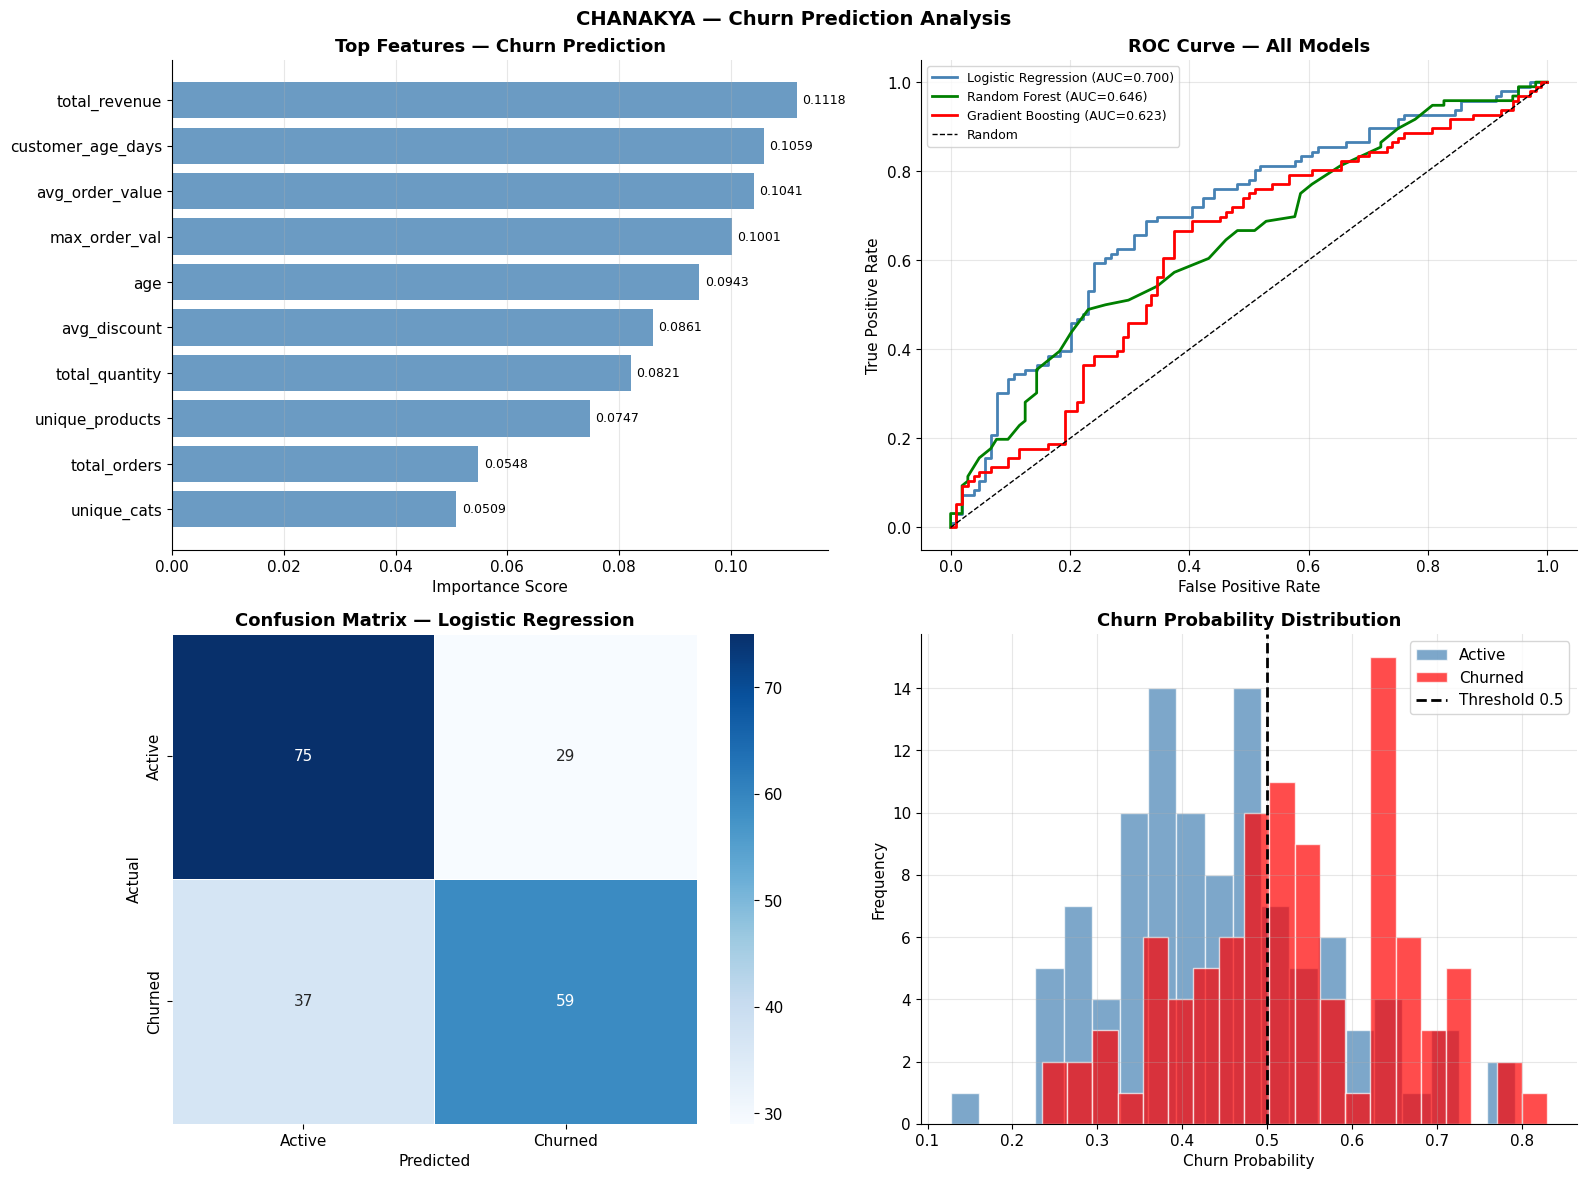

Chart saved: 10_churn_prediction.png


In [5]:
# Feature Importance + ROC Curve + Confusion Matrix
print("=" * 55)
print("   FEATURE IMPORTANCE & VISUALIZATION")
print("=" * 55)

# Random Forest feature importance
rf_model    = models_v2['Random Forest']
imp_df      = pd.DataFrame({
    'feature'    : features_v2,
    'importance' : rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop Features for Churn Prediction:")
print(f"  {'Feature':<22} {'Importance':>12}")
print(f"  {'-'*22} {'-'*12}")
for _, row in imp_df.head(8).iterrows():
    print(f"  {row['feature']:<22} {row['importance']:>12.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — Feature Importance
imp_top = imp_df.head(10).sort_values('importance')
axes[0,0].barh(imp_top['feature'], imp_top['importance'],
               color='steelblue', alpha=0.8)
axes[0,0].set_title('Top Features — Churn Prediction',
                     fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Importance Score')
for i, val in enumerate(imp_top['importance']):
    axes[0,0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
axes[0,0].grid(axis='x', alpha=0.3)

# Plot 2 — ROC Curve all models
colors_roc = ['steelblue', 'green', 'red']
for (name, proba), color in zip(proba_v2.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test2, proba)
    auc         = results_v2[name]['roc_auc']
    axes[0,1].plot(fpr, tpr, color=color, linewidth=2,
                   label=f'{name} (AUC={auc:.3f})')
axes[0,1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0,1].set_title('ROC Curve — All Models', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(alpha=0.3)

# Plot 3 — Confusion Matrix — Best Model
best_pred = predictions_v2[best_v2]
cm        = confusion_matrix(y_test2, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'],
            ax=axes[1,0], linewidths=0.5)
axes[1,0].set_title(f'Confusion Matrix — {best_v2}',
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# Plot 4 — Churn Risk Distribution
best_proba = proba_v2[best_v2]
axes[1,1].hist(best_proba[y_test2==0], bins=20, alpha=0.7,
               color='steelblue', label='Active', edgecolor='white')
axes[1,1].hist(best_proba[y_test2==1], bins=20, alpha=0.7,
               color='red', label='Churned', edgecolor='white')
axes[1,1].axvline(x=0.5, color='black', linestyle='--',
                   linewidth=2, label='Threshold 0.5')
axes[1,1].set_title('Churn Probability Distribution',
                     fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Churn Probability')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle('CHANAKYA — Churn Prediction Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHURN_PATH}/10_churn_prediction.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 10_churn_prediction.png")

#### - Churn Prediction Complete Summary

In [6]:
print("=" * 55)
print("   CHANAKYA — LAYER 9 COMPLETE!")
print("   Churn Prediction")
print("=" * 55)

print(f"\nCHURN ANALYSIS SUMMARY:")
print(f"-" * 55)
print(f"  Total Customers    : {len(churn_df):,}")
print(f"  Churned            : {churned:,} (47.9%)")
print(f"  Active             : {active:,} (52.1%)")
print(f"  Churn Threshold    : 180 days")

print(f"\nMODEL PERFORMANCE:")
print(f"-" * 55)
print(f"  {'Model':<22} {'Accuracy':>9} {'ROC-AUC':>9} {'Winner'}")
print(f"  {'-'*22} {'-'*9} {'-'*9} {'-'*8}")
for name, res in results_v2.items():
    winner = 'BEST' if name == best_v2 else ''
    print(f"  {name:<22} {res['accuracy']:>9.4f} {res['roc_auc']:>9.4f} {winner:>8}")

print(f"\nTOP CHURN INDICATORS:")
print(f"-" * 55)
for _, row in imp_df.head(5).iterrows():
    print(f"  {row['feature']:<22} : {row['importance']:.4f}")

print(f"\nCONFUSION MATRIX — {best_v2}:")
print(f"-" * 55)
cm = confusion_matrix(y_test2, predictions_v2[best_v2])
print(f"  True Active    (correct) : {cm[0][0]}")
print(f"  False Churned  (wrong)   : {cm[0][1]}")
print(f"  False Active   (wrong)   : {cm[1][0]}")
print(f"  True Churned   (correct) : {cm[1][1]}")

print(f"\nBUSINESS RECOMMENDATIONS:")
print(f"-" * 55)
print(f"  1. High churn risk — total_revenue low customers")
print(f"  2. Older customers churn more — loyalty program needed")
print(f"  3. Low avg order value — upsell campaigns")
print(f"  4. High discount users — price sensitive segment")
print(f"  5. Target 477 churned — win-back campaigns")

print(f"\nDATA LEAKAGE LESSON:")
print(f"-" * 55)
print(f"  v1 — days_since_last included — 100% accuracy (WRONG!)")
print(f"  v2 — days_since_last removed  — 67% accuracy (CORRECT)")
print(f"  Learning — always check for data leakage in features!")

print(f"\nINTERVIEW READY — KEY POINTS:")
print(f"-" * 55)
print(f"  1. Churn defined — 180 days inactivity threshold")
print(f"  2. 3 models compared — LR, RF, Gradient Boosting")
print(f"  3. Data leakage detected and fixed")
print(f"  4. ROC-AUC metric — better than accuracy for churn")
print(f"  5. Business recommendations delivered")

print(f"\nDATA READY FOR:")
print(f"  Layer 10 — Power BI Dashboard")
print(f"  Layer 11 — Agentic AI")

print("\n" + "=" * 55)
print("   LAYER 9 COMPLETE — Churn Prediction Done!")
print("=" * 55)

   CHANAKYA — LAYER 9 COMPLETE!
   Churn Prediction

CHURN ANALYSIS SUMMARY:
-------------------------------------------------------
  Total Customers    : 996
  Churned            : 477 (47.9%)
  Active             : 519 (52.1%)
  Churn Threshold    : 180 days

MODEL PERFORMANCE:
-------------------------------------------------------
  Model                   Accuracy   ROC-AUC Winner
  ---------------------- --------- --------- --------
  Logistic Regression       0.6700    0.6999     BEST
  Random Forest             0.6000    0.6460         
  Gradient Boosting         0.6150    0.6231         

TOP CHURN INDICATORS:
-------------------------------------------------------
  total_revenue          : 0.1118
  customer_age_days      : 0.1059
  avg_order_value        : 0.1041
  max_order_val          : 0.1001
  age                    : 0.0943

CONFUSION MATRIX — Logistic Regression:
-------------------------------------------------------
  True Active    (correct) : 75
  False Churned 

In [7]:
# Animated Churn Risk Visualization
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

# Churn probability for all customers
all_proba = models_v2['Logistic Regression'].predict_proba(X_test2_scaled)[:, 1]
all_actual = y_test2.values

# Separate active and churned
active_proba  = all_proba[all_actual == 0]
churned_proba = all_proba[all_actual == 1]

# Risk buckets
def get_risk(p):
    if p >= 0.7:   return 'High Risk',   '#F44336'
    elif p >= 0.4: return 'Medium Risk', '#FF9800'
    else:          return 'Low Risk',    '#4CAF50'

risk_buckets = {
    'Low Risk'    : {'count': sum(1 for p in all_proba if p < 0.4),    'color': '#4CAF50'},
    'Medium Risk' : {'count': sum(1 for p in all_proba if 0.4<=p<0.7), 'color': '#FF9800'},
    'High Risk'   : {'count': sum(1 for p in all_proba if p >= 0.7),   'color': '#F44336'},
}

FRAMES = 80

def animate(frame):
    ax.clear()
    ax.set_facecolor('#0D1117')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='white')

    progress = frame / FRAMES

    # Animate scatter plot — customers appearing one by one
    n_show = int(progress * len(all_proba))

    # Color each customer by risk
    colors_scatter = []
    for p in all_proba[:n_show]:
        if p >= 0.7:   colors_scatter.append('#F44336')
        elif p >= 0.4: colors_scatter.append('#FF9800')
        else:          colors_scatter.append('#4CAF50')

    if n_show > 0:
        ax.scatter(
            range(n_show),
            all_proba[:n_show],
            c=colors_scatter, alpha=0.7, s=40, zorder=3
        )

    # Threshold lines
    ax.axhline(y=0.7, color='#F44336', linestyle='--',
               linewidth=1.5, alpha=0.6, label='High Risk Threshold')
    ax.axhline(y=0.4, color='#FF9800', linestyle='--',
               linewidth=1.5, alpha=0.6, label='Medium Risk Threshold')

    # Risk zone shading
    ax.axhspan(0.7, 1.0, alpha=0.05, color='#F44336')
    ax.axhspan(0.4, 0.7, alpha=0.05, color='#FF9800')
    ax.axhspan(0.0, 0.4, alpha=0.05, color='#4CAF50')

    # Risk labels on right
    ax.text(len(all_proba)*1.02, 0.85, 'HIGH RISK',
            color='#F44336', fontsize=9, fontweight='bold', va='center')
    ax.text(len(all_proba)*1.02, 0.55, 'MEDIUM RISK',
            color='#FF9800', fontsize=9, fontweight='bold', va='center')
    ax.text(len(all_proba)*1.02, 0.20, 'LOW RISK',
            color='#4CAF50', fontsize=9, fontweight='bold', va='center')

    # Live counter
    if n_show > 0:
        high   = sum(1 for p in all_proba[:n_show] if p >= 0.7)
        medium = sum(1 for p in all_proba[:n_show] if 0.4 <= p < 0.7)
        low    = sum(1 for p in all_proba[:n_show] if p < 0.4)

        ax.text(0.02, 0.95,
                f'High Risk: {high}  |  Medium: {medium}  |  Low: {low}',
                transform=ax.transAxes, color='white',
                fontsize=11, fontweight='bold')

    ax.set_xlim(-2, len(all_proba) * 1.18)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel('Customer Index', color='white', fontsize=11)
    ax.set_ylabel('Churn Probability', color='white', fontsize=11)
    ax.set_title('CHANAKYA — Live Churn Risk Assessment',
                 color='white', fontsize=14, fontweight='bold', pad=15)

    # Progress
    ax.text(0.99, 0.02, f'{int(progress*100)}%',
            transform=ax.transAxes, color='#2196F3',
            fontsize=12, fontweight='bold', ha='right')

    return []

ani = FuncAnimation(
    fig, animate,
    frames   = FRAMES,
    interval = 50,
    repeat   = False
)

plt.close()
HTML(ani.to_jshtml())